# Problem 1: Prediction of Rf value for TLC analysis
## Q1: Download and understand the data

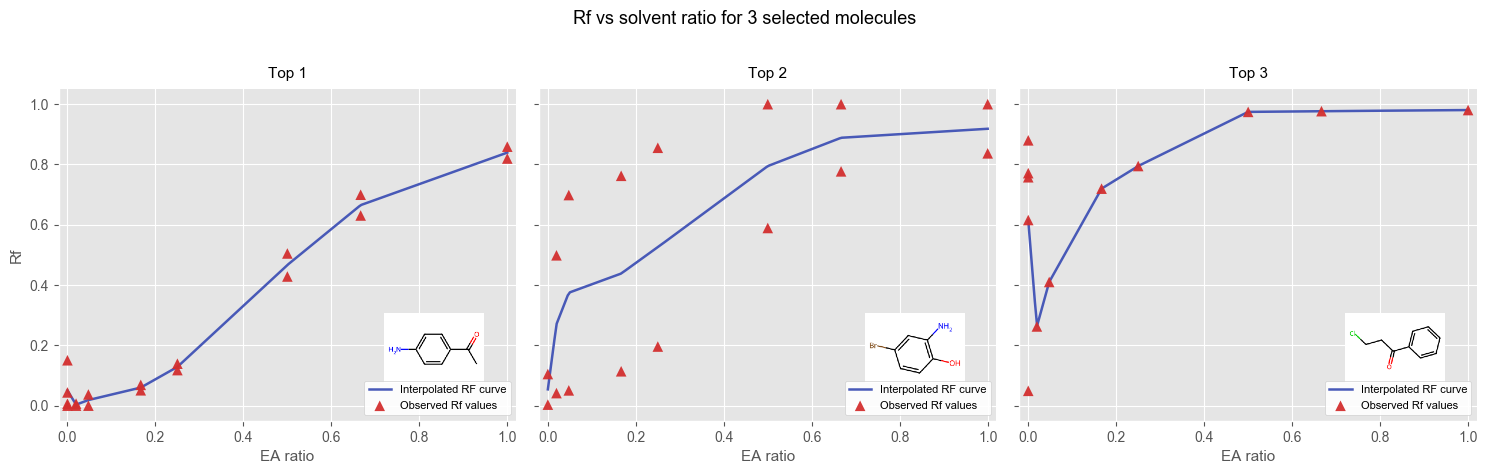

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from rdkit import Chem
from rdkit.Chem import Draw

# 配置中文字体
plt.rcParams["font.sans-serif"] = [
    "PingFang SC",
    "Heiti SC",
    "Arial Unicode MS",
    "Noto Sans CJK SC",
    "SimHei",
]
plt.rcParams["axes.unicode_minus"] = False

# 读取并清洗 TLC 数据集
def load_clean_data(filepath="TLC_dataset.xlsx"):
    """
    读取 TLC 数据并执行基础清洗：
    删除 COMPOUND_SMILES 或 Rf 缺失的记录，仅保留 RDKit 可解析的合法 SMILES
    """
    df = pd.read_excel(filepath)
    df = df.dropna(subset=["COMPOUND_SMILES", "Rf"] )

    valid_smiles_mask = df["COMPOUND_SMILES"].apply(
        lambda x: Chem.MolFromSmiles(str(x)) is not None
    )
    df_clean = df[valid_smiles_mask].copy()
    return df_clean


def _right_bottom_image(x_data, y_data):
    """
    绘图辅助函数，用于估计标签在右下区域的 y 坐标，尽量避免遮挡曲线。
    返回值在 [0, 1] 的 axes fraction 坐标系中。
    """
    if x_data is None or y_data is None or len(x_data) == 0:
        return 0.30

    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    x_min, x_max = np.min(x_data), np.max(x_data)
    if x_max - x_min < 1e-12:
        y_right = float(np.mean(y_data))
    else:
        x_norm = (x_data - x_min) / (x_max - x_min)
        right_mask = x_norm >= 0.70
        y_right = float(np.mean(y_data[right_mask])) if np.any(right_mask) else float(np.mean(y_data))

    # 右侧曲线偏高时，把分子图放得更低；否则稍微上移但仍保持右下区域
    if y_right > 0.65:
        return 0.22
    if y_right > 0.45:
        return 0.28
    return 0.35


def _add_molecule_image(ax, smiles, x_data=None, y_data=None, image_size=(170, 120), zoom=0.42):
    """绘图辅助函数 在子图右下区域添加分子结构图，并尽量避开曲线。"""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return

    y_center = _right_bottom_image(x_data, y_data)
    mol_image = Draw.MolToImage(mol, size=image_size)
    image_box = OffsetImage(mol_image, zoom=zoom)
    annotation = AnnotationBbox(
        image_box,
        (0.82, y_center),
        xycoords="axes fraction",
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=1,
    )
    ax.add_artist(annotation)


def _apply_right_bottom(ax, fontsize=8):
    """统一图例样式：放在右下角，尽量不遮挡主曲线。"""
    ax.legend(
        loc="lower right",
        fontsize=fontsize,
        frameon=True,
        framealpha=0.90,
        facecolor="white",
        edgecolor="#cccccc",
    )


# 固定绘制 3 个分子的 Rf-溶剂比例关系图
def plot_rf_distribution(df, selected_smiles_list=None):
    """
    绘制 3 个分子的 Rf 与溶剂比例关系图（H-EA）
    - selected_smiles_list 为空时，默认使用出现频率最高的前 3 个分子
    - 子图标题直接使用对应分子的 SMILES
    """
    df = df.copy()  # 避免修改传入的原始数据

    df["H_EA_sum"] = df["H"] + df["EA"]
    df_ratio = df[df["H_EA_sum"] > 0].copy()
    df_ratio["EA_ratio"] = df_ratio["EA"] / df_ratio["H_EA_sum"] # 计算 EA 比例

    # 固定选择 3 个分子
    if selected_smiles_list is None:
        selected_smiles = (
            df_ratio["COMPOUND_SMILES"]
            .value_counts()
            .head(3)
            .index
            .tolist()
        )
    else:
        selected_smiles = list(selected_smiles_list)[:3]

    # 如果数据里不足 3 个唯一分子，则按实际可用数量绘图
    n_panels = len(selected_smiles)
    if n_panels == 0:
        raise ValueError("没有可用于绘图的有效分子。")

    # 使用与论文风格接近的面板样式
    plt.style.use("ggplot")
    fig, axes = plt.subplots(
        1, n_panels, figsize=(5.0 * n_panels, 4.6), sharey=True
    )
    if n_panels == 1:
        axes = [axes]

    for axis, smiles in zip(axes, selected_smiles):
        subset = df_ratio[df_ratio["COMPOUND_SMILES"] == smiles].copy()
        subset = subset.sort_values(by="EA_ratio")

        x_obs = subset["EA_ratio"].to_numpy(dtype=float)
        y_obs = subset["Rf"].to_numpy(dtype=float)

        # 若 x 有重复点，先按相同 x 的 y 均值合并，确保插值稳定
        unique_x, inverse_index = np.unique(x_obs, return_inverse=True)
        if len(unique_x) < len(x_obs):
            y_sum = np.zeros_like(unique_x, dtype=float)
            y_count = np.zeros_like(unique_x, dtype=float)
            np.add.at(y_sum, inverse_index, y_obs)
            np.add.at(y_count, inverse_index, 1.0)
            y_unique = y_sum / y_count
        else:
            y_unique = y_obs

        # 分段线性插值
        if len(unique_x) >= 2:
            x_line = np.linspace(unique_x.min(), unique_x.max(), 200)
            y_line = np.interp(x_line, unique_x, y_unique)
            axis.plot(
                x_line,
                y_line,
                color="#3f51b5",
                linewidth=1.8,
                alpha=0.95,
                label="Interpolated RF curve",
                zorder=2,
            )

        # 观测散点
        axis.scatter(
            x_obs,
            y_obs,
            marker="^",
            s=58,
            color="#d32f2f",
            edgecolor="none",
            alpha=0.95,
            label="Observed Rf values",
            zorder=3,
        )

        # 统一右下角图像和图例风格
        _add_molecule_image(axis, smiles, x_data=x_obs, y_data=y_obs)
        _apply_right_bottom(axis, fontsize=8)

        axis.set_title(f"{smiles}", fontsize=11, pad=8)
        axis.set_xlabel("EA ratio", fontsize=11)
        axis.set_xlim(-0.02, 1.02)
        axis.set_ylim(-0.05, 1.05)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)

    axes[0].set_ylabel("Rf", fontsize=11)
    fig.suptitle("Rf vs solvent ratio for 3 selected molecules", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


df = load_clean_data("TLC_dataset.xlsx")
plot_rf_distribution(df)

## Q2: Build a neural network model to predict Rf
### Task 1: Correctly convert SMILES to fingerprints

In [22]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

def smiles_to_fingerprint(smiles, fp_type='morgan', radius=3, fpSize=128):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # Return an array of zeros if the SMILES conversion fails.
        return np.zeros(fpSize, dtype=int)
    if fp_type == 'morgan':
        generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    elif fp_type == 'rdkit':
        generator = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=fpSize)
    elif fp_type == 'atompair':
        generator = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=fpSize)
    elif fp_type == 'topological':
        generator = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=fpSize)
    else:
        raise ValueError(f"Unsupported fingerprint type: {fp_type}")

    fp = generator.GetFingerprint(mol)
    arr = np.zeros((fpSize,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

### Task 2: Prepare the dataset for training and testing

In [9]:
def prepare_dataset(df, fp_type='morgan', fpSize=128):
    """
    组装特征矩阵 X 和目标向量 y，并切分数据集。
    """
    X_list = []
    y_list = []
    
    solvent_cols = ['H', 'EA', 'DCM', 'MeOH', 'Et2O']
    
    for _, row in df.iterrows():
        # 获取指纹
        fp_array = smiles_to_fingerprint(row['COMPOUND_SMILES'], fp_type=fp_type, fpSize=fpSize)
        
        solvent_array = row[solvent_cols].values.astype(float) # 提取溶剂特征并转换为numpy array
        X_i = np.concatenate([fp_array, solvent_array])
        
        X_list.append(X_i)
        y_list.append(row['Rf'])
        
    X = np.array(X_list)
    y = np.array(y_list).reshape(-1, 1)
    
    # 划分数据集为训练集和测试集，比例为8/2
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    return X_train, X_test, y_train, y_test

### Task 3: Build a neural network model

In [10]:
import pickle

#————————————————————————————定义激活函数——————————————————————————
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    # derivative of ReLU wrt z
    dz = np.zeros_like(z)
    dz[z > 0] = 1.0
    return dz

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    # derivative of sigmoid wrt z
    s = sigmoid(z)
    return s * (1 - s)

def linear(z):
    return z

def linear_derivative(z):
    # derivative of linear is 1
    return np.ones_like(z)

def softmax(z):
    """
    z: shape (N, C) where N is the number of samples and C is the number of classes
    Returns the softmax probabilities for each class.
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Stability trick: subtract max(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def softmax_derivative(z):
    """
    Will not use
    """
    return None

# ——————————————————————————————————定义全连接（隐藏层）————————————————————————————————
class FullyConnectedLayer:
    def __init__(self, input_dim, output_dim, activation='relu', dim_output=False):
        """
        A_in is shape (N, input_dim).
        This layer has W of shape (input_dim, output_dim).
        """
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.dim_output = dim_output
        self.Z = None      # pre-activation
        self.A_in = None   # input to this layer
        self.A_out = None  # output from this layer (after activation)
       
        # He initialization: helps gradients flow properly in deep networks
        self.W = np.random.randn(input_dim, output_dim) * (1.0 / np.sqrt(input_dim))
        self.b = np.zeros((1, output_dim)) # w_0
       
        if activation == 'relu':
           self.activation = relu
           self.activation_deriv = relu_derivative
        elif activation == 'sigmoid':
           self.activation = sigmoid
           self.activation_deriv = sigmoid_derivative
        elif activation == 'softmax':
            self.activation = softmax
            self.activation_deriv = softmax_derivative  # gradient via combined shortcut
        else:
            self.activation = linear
            self.activation_deriv = linear_derivative

    def forward(self, A_in):
        """
        A_in is shape (N, input_dim).
        This layer has W of shape (input_dim, output_dim).
        """
        self.A_in = A_in  # needed for backward
        # compute pre-activation
        self.Z = self.A_in @ self.W + self.b  # shape (N, output_dim)
        # print dimensions
        self.print_dims("Forward pass (Z, A_in)", self.Z, self.A_in)
        # apply activation
        self.A_out = self.activation(self.Z)
        self.print_dims("Forward pass (A_out)", self.A_out)
        return self.A_out

    def backward(self, dA_out, y_true=None, is_output_layer=False):
        """
        w.r.t.: with respect to
        dA_out is the gradient of the loss w.r.t. this layer's output A_out.
        We need to compute and return:
            dA_in = gradient w.r.t. A_in
            dW    = gradient w.r.t. W
            db    = gradient w.r.t. b
        """
        # dZ = d(loss)/dZ = d(loss)/d(A_out) * d(A_out)/dZ
        # For Binary classification, this simplifies to (A_out - y_true)
        if is_output_layer:
            dZ = self.A_out-y_true.reshape(self.A_out.shape) # shape (N, output_dim)
        else:
            dZ = dA_out * self.activation_deriv(self.Z)  # shape (N, output_dim)
        self.print_dims("Backward pass (dZ)", dZ)
        
        # dW = (A_in^T @ dZ) / N  — averaged over the batch
        dW = (self.A_in.T @ dZ) / dZ.shape[0]
        self.print_dims("Backward pass (dW)", dW)

        # db = mean of dZ over samples
        db = np.sum(dZ, axis=0, keepdims=True) / dZ.shape[0]
        self.print_dims("Backward pass (db)", db)
        
        # dA_in = dZ * W^T
        dA_in = dZ @ self.W.T # shape (N, input_dim)
        self.print_dims("Backward pass (dA_in)", dA_in)
        
        return dA_in, dW, db
        
    def print_dims(self, label, *args):
        if self.dim_output:
            print(f"{label}: ", end="")
            for array in args:
                print(array.shape, end=" ")
            print()

#————————————————————————————————定义神经网络————————————————————————————————
class NeuralNetwork:
    def __init__(self, layers_config):
        """
        layers_config is a list of tuples:
          [(input_dim1, output_dim1, activation1),
           (input_dim2, output_dim2, activation2),
           ...
          ]
        We'll create a FullyConnectedLayer for each tuple.
        """
        self.layers = []
        for (in_dim, out_dim, activation) in layers_config:
            layer = FullyConnectedLayer(in_dim, out_dim, activation=activation)
            self.layers.append(layer)
    
    def forward(self, X):
        """
        Forward pass through all layers.
        X is shape (N, input_dim of first layer).
        """
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A  # final output
    
    def backward(self, dA, y_true):
        """Backward pass through all layers (in reverse). Returns gradients for each layer."""
        grads = []
        for i, layer in reversed(list(enumerate(self.layers))):
            if i == len(self.layers) - 1:  # Output layer
                dA, dW, db = layer.backward(dA_out=dA, y_true=y_true, is_output_layer=True)
            else:  # Hidden layers
                dA, dW, db = layer.backward(dA_out=dA)
            grads.append((dW, db))
        # grads are collected in reverse order
        grads.reverse()
        return grads
    
    def update_params(self, grads, lr=0.001):
        """
        Update each layer's W, b with the corresponding gradients.
        grads is a list of (dW, db) for each layer in forward order.
        """
        for (layer, (dW, db)) in zip(self.layers, grads):
            layer.W -= lr * dW
            layer.b -= lr * db
    #————————————————————————定义保存模型和加载模型————————————————————————————————
    def save_model(self, file_path):
        """
        Saves the neural network's weights and biases to a file.
        """
        model_data = {
            "layers_config": [(layer.W.shape[0], layer.W.shape[1], layer.activation.__name__) for layer in self.layers],
            "weights": [layer.W for layer in self.layers],
            "biases": [layer.b for layer in self.layers]
        }
        with open(file_path, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"Model saved to {file_path}")

    @staticmethod
    def load_model(file_path):
        """
        Loads a saved neural network model from a file.
        """
        with open(file_path, 'rb') as f:
            model_data = pickle.load(f)

        nn = NeuralNetwork(model_data["layers_config"])
        for layer, W, b in zip(nn.layers, model_data["weights"], model_data["biases"]):
            layer.W = W
            layer.b = b
        
        print(f"Model loaded from {file_path}")
        return nn

def mse_loss(y_pred, y_true):
    """均方误差损失"""
    return np.mean((y_pred - y_true) ** 2)

def clip_predictions(preds):
    """
    针对线性激活函数的输出进行截断
    将 >1 的值设为1，<0 的值设为0
    """
    return np.clip(preds, 0.0, 1.0)

def train_network(model, X_train, y_train, lr=0.001, max_epoch=100, batch_size=32):
    """
    Mini-batch 训练回归模型
    """
    for layer in model.layers: 
        layer.dim_output = False
        
    loss_history = []
    n_samples = X_train.shape[0]
    
    for epoch in range(max_epoch):
        # 打乱数据
        indices = np.random.permutation(n_samples)
        X_shuf, y_shuf = X_train[indices], y_train[indices]
        
        for i in range(0, n_samples, batch_size):
            X_batch, y_batch = X_shuf[i:i+batch_size], y_shuf[i:i+batch_size]
            
            y_pred = model.forward(X_batch) # 前向传播
            
            
            dA_out = 2 * (y_pred - y_batch) # 计算初始梯度 dA_out
            
            #反向传播 
            grads = []
            dA = dA_out
            for j, layer in reversed(list(enumerate(model.layers))):
                dA, dW, db = layer.backward(dA_out=dA, y_true=y_batch, is_output_layer=False)
                grads.append((dW, db))
            grads.reverse()
            
            model.update_params(grads, lr=lr) # 更新参数
            
        # 记录 Epoch 级别的 Loss
        y_pred_full = model.forward(X_train)
        current_loss = mse_loss(y_pred_full, y_train)
        loss_history.append(current_loss)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{max_epoch} | MSE Loss: {current_loss:.4f}")
            
    return loss_history

### Task 4: Train the model

Loading data...

Selected configs:
- A. Mid-Sigmoid-Morgan: fp=morgan, hidden=[64, 32], out=sigmoid
- B. Mid-Sigmoid-RDKit: fp=rdkit, hidden=[64, 32], out=sigmoid
- C. Mid-Sigmoid-AtomPair: fp=atompair, hidden=[64, 32], out=sigmoid
- D. Mid-Sigmoid-Topological: fp=topological, hidden=[64, 32], out=sigmoid
- E. Mid-Linear-RDKit: fp=rdkit, hidden=[64, 32], out=linear
- F. Shadow-Linear-RDKit: fp=rdkit, hidden=[32], out=linear
- G. Shadow-Sigmoid-RDKit: fp=rdkit, hidden=[32], out=sigmoid
- H. Deep1-Linear-RDKit: fp=rdkit, hidden=[128, 64, 32], out=linear
- I. Deep1-Sigmoid-RDKit: fp=rdkit, hidden=[128, 64, 32], out=sigmoid
- J. Deep2-Linear-RDKit: fp=rdkit, hidden=[512, 256, 128, 64, 32], out=linear
- K. Deep2-Sigmoid-RDKit: fp=rdkit, hidden=[512, 256, 128, 64, 32], out=sigmoid

Running A. Mid-Sigmoid-Morgan
Epoch   1/100 | MSE Loss: 0.1255
Epoch  10/100 | MSE Loss: 0.1151
Epoch  20/100 | MSE Loss: 0.1104
Epoch  30/100 | MSE Loss: 0.1082
Epoch  40/100 | MSE Loss: 0.1069
Epoch  50/100 | MS

Loading data...

Selected configs:
- A. Mid-Sigmoid-Morgan: fp=morgan, hidden=[64, 32], out=sigmoid
- B. Mid-Sigmoid-RDKit: fp=rdkit, hidden=[64, 32], out=sigmoid
- C. Mid-Sigmoid-AtomPair: fp=atompair, hidden=[64, 32], out=sigmoid
- D. Mid-Sigmoid-Topological: fp=topological, hidden=[64, 32], out=sigmoid
- E. Mid-Linear-RDKit: fp=rdkit, hidden=[64, 32], out=linear
- F. Shadow-Linear-RDKit: fp=rdkit, hidden=[32], out=linear
- G. Shadow-Sigmoid-RDKit: fp=rdkit, hidden=[32], out=sigmoid
- H. Deep1-Linear-RDKit: fp=rdkit, hidden=[128, 64, 32], out=linear
- I. Deep1-Sigmoid-RDKit: fp=rdkit, hidden=[128, 64, 32], out=sigmoid
- J. Deep2-Linear-RDKit: fp=rdkit, hidden=[512, 256, 128, 64, 32], out=linear
- K. Deep2-Sigmoid-RDKit: fp=rdkit, hidden=[512, 256, 128, 64, 32], out=sigmoid

Running A. Mid-Sigmoid-Morgan
Epoch   1/100 | MSE Loss: 0.1255
Epoch  10/100 | MSE Loss: 0.1151
Epoch  20/100 | MSE Loss: 0.1104
Epoch  30/100 | MSE Loss: 0.1082
Epoch  40/100 | MSE Loss: 0.1069
Epoch  50/100 | MS

,name,fp_type,hidden_dims,output_activation,layers_config,test_mse
0,J. Deep2-Linear-RDKit,rdkit,"[512, 256, 128, 64, 32]",linear,"[(133, 512, 'relu'), (512, 256, 'relu'), (256,...",0.039769
1,F. Shadow-Linear-RDKit,rdkit,[32],linear,"[(133, 32, 'relu'), (32, 1, 'linear')]",0.049888
2,H. Deep1-Linear-RDKit,rdkit,"[128, 64, 32]",linear,"[(133, 128, 'relu'), (128, 64, 'relu'), (64, 3...",0.050463
3,E. Mid-Linear-RDKit,rdkit,"[64, 32]",linear,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.053130
4,K. Deep2-Sigmoid-RDKit,rdkit,"[512, 256, 128, 64, 32]",sigmoid,"[(133, 512, 'relu'), (512, 256, 'relu'), (256,...",0.090354
5,B. Mid-Sigmoid-RDKit,rdkit,"[64, 32]",sigmoid,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.093410
6,G. Shadow-Sigmoid-RDKit,rdkit,[32],sigmoid,"[(133, 32, 'relu'), (32, 1, 'sigmoid')]",0.094793
7,I. Deep1-Sigmoid-RDKit,rdkit,"[128, 64, 32]",sigmoid,"[(133, 128, 'relu'), (128, 64, 'relu'), (64, 3...",0.100910
8,A. Mid-Sigmoid-Morgan,morgan,"[64, 32]",sigmoid,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.101663
9,C. Mid-Sigmoid-AtomPair,atompair,"[64, 32]",sigmoid,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.103722


Loading data...

Selected configs:
- A. Mid-Sigmoid-Morgan: fp=morgan, hidden=[64, 32], out=sigmoid
- B. Mid-Sigmoid-RDKit: fp=rdkit, hidden=[64, 32], out=sigmoid
- C. Mid-Sigmoid-AtomPair: fp=atompair, hidden=[64, 32], out=sigmoid
- D. Mid-Sigmoid-Topological: fp=topological, hidden=[64, 32], out=sigmoid
- E. Mid-Linear-RDKit: fp=rdkit, hidden=[64, 32], out=linear
- F. Shadow-Linear-RDKit: fp=rdkit, hidden=[32], out=linear
- G. Shadow-Sigmoid-RDKit: fp=rdkit, hidden=[32], out=sigmoid
- H. Deep1-Linear-RDKit: fp=rdkit, hidden=[128, 64, 32], out=linear
- I. Deep1-Sigmoid-RDKit: fp=rdkit, hidden=[128, 64, 32], out=sigmoid
- J. Deep2-Linear-RDKit: fp=rdkit, hidden=[512, 256, 128, 64, 32], out=linear
- K. Deep2-Sigmoid-RDKit: fp=rdkit, hidden=[512, 256, 128, 64, 32], out=sigmoid

Running A. Mid-Sigmoid-Morgan
Epoch   1/100 | MSE Loss: 0.1255
Epoch  10/100 | MSE Loss: 0.1151
Epoch  20/100 | MSE Loss: 0.1104
Epoch  30/100 | MSE Loss: 0.1082
Epoch  40/100 | MSE Loss: 0.1069
Epoch  50/100 | MS

,name,fp_type,hidden_dims,output_activation,layers_config,test_mse
0,J. Deep2-Linear-RDKit,rdkit,"[512, 256, 128, 64, 32]",linear,"[(133, 512, 'relu'), (512, 256, 'relu'), (256,...",0.039769
1,F. Shadow-Linear-RDKit,rdkit,[32],linear,"[(133, 32, 'relu'), (32, 1, 'linear')]",0.049888
2,H. Deep1-Linear-RDKit,rdkit,"[128, 64, 32]",linear,"[(133, 128, 'relu'), (128, 64, 'relu'), (64, 3...",0.050463
3,E. Mid-Linear-RDKit,rdkit,"[64, 32]",linear,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.053130
4,K. Deep2-Sigmoid-RDKit,rdkit,"[512, 256, 128, 64, 32]",sigmoid,"[(133, 512, 'relu'), (512, 256, 'relu'), (256,...",0.090354
5,B. Mid-Sigmoid-RDKit,rdkit,"[64, 32]",sigmoid,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.093410
6,G. Shadow-Sigmoid-RDKit,rdkit,[32],sigmoid,"[(133, 32, 'relu'), (32, 1, 'sigmoid')]",0.094793
7,I. Deep1-Sigmoid-RDKit,rdkit,"[128, 64, 32]",sigmoid,"[(133, 128, 'relu'), (128, 64, 'relu'), (64, 3...",0.100910
8,A. Mid-Sigmoid-Morgan,morgan,"[64, 32]",sigmoid,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.101663
9,C. Mid-Sigmoid-AtomPair,atompair,"[64, 32]",sigmoid,"[(133, 64, 'relu'), (64, 32, 'relu'), (32, 1, ...",0.103722


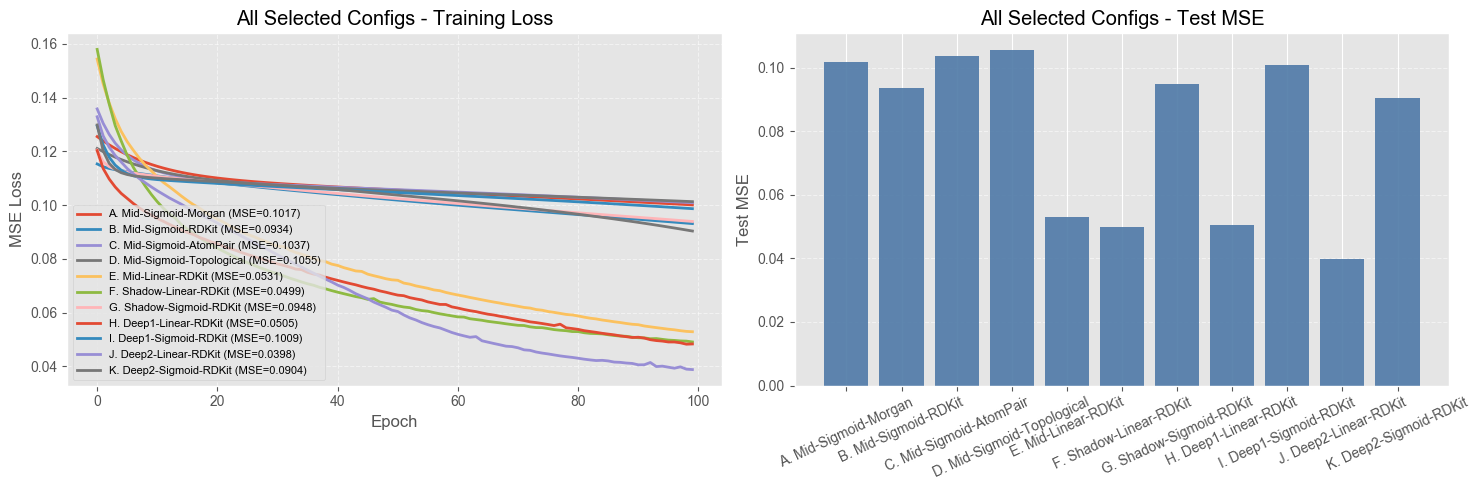


BEST_MODEL_CONFIG updated for Q4:
{'fp_type': 'rdkit', 'fp_size': 128, 'hidden_dims': [512, 256, 128, 64, 32], 'output_activation': 'linear', 'learning_rate': 0.001, 'max_epoch': 100, 'batch_size': 32, 'test_size': 0.2, 'random_state': 42}


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_layer_config(input_dim, hidden_dims, output_activation):
    """根据隐藏层配置构建网络结构。"""
    layers = []
    prev_dim = input_dim
    for h in hidden_dims:
        layers.append((prev_dim, h, "relu"))
        prev_dim = h
    layers.append((prev_dim, 1, output_activation))
    return layers


def run_config_experiment(df, cfg):
    """运行单个配置并返回结果。"""
    X_train, X_test, y_train, y_test = prepare_dataset(
        df, fp_type=cfg["fp_type"], fpSize=cfg["fp_size"]
    )
    input_dim = X_train.shape[1]
    layers_config = build_layer_config(
        input_dim=input_dim,
        hidden_dims=cfg["hidden_dims"],
        output_activation=cfg["output_activation"],
    )

    model = NeuralNetwork(layers_config)
    loss_hist = train_network(
        model,
        X_train,
        y_train,
        lr=cfg["learning_rate"],
        max_epoch=cfg["max_epoch"],
        batch_size=cfg["batch_size"],
    )

    y_pred_test = model.forward(X_test)
    if cfg["output_activation"] == "linear":
        y_pred_test = clip_predictions(y_pred_test)
    test_mse = float(mse_loss(y_pred_test, y_test))

    return {
        "name": cfg["name"],
        "fp_type": cfg["fp_type"],
        "hidden_dims": list(cfg["hidden_dims"]),
        "output_activation": cfg["output_activation"],
        "layers_config": layers_config,
        "loss_hist": loss_hist,
        "test_mse": test_mse,
    }


# 所有配置共享的默认参数
EXPERIMENT_DEFAULTS = {
    "fp_size": 128,
    "learning_rate": 0.001,
    "max_epoch": 100,
    "batch_size": 32,
}

# 大配置池：
# 1. different fingerprints
# 2. sigmoid and linear output activation 
# 3. different model structure
EXPERIMENT_CONFIG_POOL = [
    {
        "name": "A. Mid-Sigmoid-Morgan",
        "fp_type": "morgan",
        "hidden_dims": [64, 32],
        "output_activation": "sigmoid",
    },
    {
        "name": "B. Mid-Sigmoid-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [64, 32],
        "output_activation": "sigmoid",
    },
    {
        "name": "C. Mid-Sigmoid-AtomPair",
        "fp_type": "atompair",
        "hidden_dims": [64, 32],
        "output_activation": "sigmoid",
    },
    {
        "name": "D. Mid-Sigmoid-Topological",
        "fp_type": "topological",
        "hidden_dims": [64, 32],
        "output_activation": "sigmoid",
    },
        {
        "name": "E. Mid-Linear-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [64, 32],
        "output_activation": "linear",
    },
    {
        "name": "F. Shadow-Linear-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [32],
        "output_activation": "linear",
    },
    {
        "name": "G. Shadow-Sigmoid-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [32],
        "output_activation": "sigmoid",
    },
    {
        "name": "H. Deep1-Linear-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [128, 64, 32],
        "output_activation": "linear",
    },
    {
        "name": "I. Deep1-Sigmoid-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [128, 64, 32],
        "output_activation": "sigmoid",
    },
    {
        "name": "J. Deep2-Linear-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [512, 256, 128, 64, 32],
        "output_activation": "linear",
    },
    {
        "name": "K. Deep2-Sigmoid-RDKit",
        "fp_type": "rdkit",
        "hidden_dims": [512, 256, 128, 64, 32],
        "output_activation": "sigmoid",
    }
]

# 选择本次要跑的配置名
SELECTED_CONFIG_NAMES = [
    "A. Mid-Sigmoid-Morgan",
    "B. Mid-Sigmoid-RDKit",
    "C. Mid-Sigmoid-AtomPair",
    "D. Mid-Sigmoid-Topological",
    "E. Mid-Linear-RDKit",
    "F. Shadow-Linear-RDKit",
    "G. Shadow-Sigmoid-RDKit",
    "H. Deep1-Linear-RDKit",
    "I. Deep1-Sigmoid-RDKit",
    "J. Deep2-Linear-RDKit",
    "K. Deep2-Sigmoid-RDKit",
]

# 用默认参数 + 差异参数合并成实际运行配置
selected_cfgs = [
    {**EXPERIMENT_DEFAULTS, **cfg}
    for cfg in EXPERIMENT_CONFIG_POOL
    if cfg["name"] in SELECTED_CONFIG_NAMES
]

if len(selected_cfgs) == 0:
    raise ValueError("SELECTED_CONFIG_NAMES 未匹配到任何配置。")

print("Loading data...")
df = load_clean_data("TLC_dataset.xlsx")

print("\nSelected configs:")
for c in selected_cfgs:
    print(
        f"- {c['name']}: fp={c['fp_type']}, hidden={c['hidden_dims']}, "
        f"out={c['output_activation']}"
    )

results = []
for cfg in selected_cfgs:
    print("\n" + "=" * 72)
    print(f"Running {cfg['name']}")
    print("=" * 72)
    res = run_config_experiment(df, cfg)
    results.append(res)
    print(f"Test MSE = {res['test_mse']:.4f}")

# 汇总结果表
summary_df = pd.DataFrame([
    {
        "name": r["name"],
        "fp_type": r["fp_type"],
        "hidden_dims": str(r["hidden_dims"]),
        "output_activation": r["output_activation"],
        "layers_config": str(r["layers_config"]),
        "test_mse": r["test_mse"],
    }
    for r in results
]).sort_values("test_mse", ascending=True).reset_index(drop=True)

print("\n=== Summary (all selected configs) ===")
display(summary_df)

# 1 张总 loss 图 + 1 张总 MSE 柱图
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：所有配置训练 loss 曲线
for r in results:
    axes[0].plot(
        r["loss_hist"],
        linewidth=2,
        label=f"{r['name']} (MSE={r['test_mse']:.4f})",
    )
axes[0].set_title("All Selected Configs - Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(fontsize=8)

# 右图：所有配置 Test MSE 柱状图
bar_names = [r["name"] for r in results]
bar_mses = [r["test_mse"] for r in results]
axes[1].bar(bar_names, bar_mses, color="#4e79a7", alpha=0.9)
axes[1].set_title("All Selected Configs - Test MSE")
axes[1].set_ylabel("Test MSE")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.5)
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

# 更新最佳模型
best_row = summary_df.iloc[0]
best_cfg = next(c for c in selected_cfgs if c["name"] == best_row["name"])
BEST_MODEL_CONFIG = {
    "fp_type": best_cfg["fp_type"],
    "fp_size": best_cfg["fp_size"],
    "hidden_dims": list(best_cfg["hidden_dims"]),
    "output_activation": best_cfg["output_activation"],
    "learning_rate": best_cfg["learning_rate"],
    "max_epoch": best_cfg["max_epoch"],
    "batch_size": best_cfg["batch_size"],
    "test_size": 0.2,
    "random_state": 42,
}

print("\nBEST_MODEL_CONFIG updated for Q4:")
print(BEST_MODEL_CONFIG)


## Q3: Evaluate the model performance

---

**具体对比详见作业报告**

---

### Task 1: Compare the performance of different fingerprints

### Task 2: Compare sigmoid and linear output activation 

### Task 3: Compare different model structure

## Q4: Case studies
### Task 1: Understand how eluent polarity (composition) affects Rf value

1) Loading data...
2) Building features using config:
{'fp_type': 'rdkit', 'fp_size': 128, 'hidden_dims': [128, 64, 32], 'output_activation': 'linear', 'learning_rate': 0.001, 'max_epoch': 100, 'batch_size': 32, 'test_size': 0.2, 'random_state': 42}
3) Training the configurable best-model candidate...
Epoch   1/100 | MSE Loss: 0.1357
Epoch  10/100 | MSE Loss: 0.1006
Epoch  20/100 | MSE Loss: 0.0863
Epoch  30/100 | MSE Loss: 0.0756
Epoch  40/100 | MSE Loss: 0.0680
Epoch  50/100 | MSE Loss: 0.0625
Epoch  60/100 | MSE Loss: 0.0579
Epoch  70/100 | MSE Loss: 0.0546
Epoch  80/100 | MSE Loss: 0.0511
Epoch  90/100 | MSE Loss: 0.0485
Epoch 100/100 | MSE Loss: 0.0462
4) Test MSE with current config: 0.0467
5) Plotting experimental vs predictive Rf for 3 test molecules...


1) Loading data...
2) Building features using config:
{'fp_type': 'rdkit', 'fp_size': 128, 'hidden_dims': [128, 64, 32], 'output_activation': 'linear', 'learning_rate': 0.001, 'max_epoch': 100, 'batch_size': 32, 'test_size': 0.2, 'random_state': 42}
3) Training the configurable best-model candidate...
Epoch   1/100 | MSE Loss: 0.1357
Epoch  10/100 | MSE Loss: 0.1006
Epoch  20/100 | MSE Loss: 0.0863
Epoch  30/100 | MSE Loss: 0.0756
Epoch  40/100 | MSE Loss: 0.0680
Epoch  50/100 | MSE Loss: 0.0625
Epoch  60/100 | MSE Loss: 0.0579
Epoch  70/100 | MSE Loss: 0.0546
Epoch  80/100 | MSE Loss: 0.0511
Epoch  90/100 | MSE Loss: 0.0485
Epoch 100/100 | MSE Loss: 0.0462
4) Test MSE with current config: 0.0467
5) Plotting experimental vs predictive Rf for 3 test molecules...


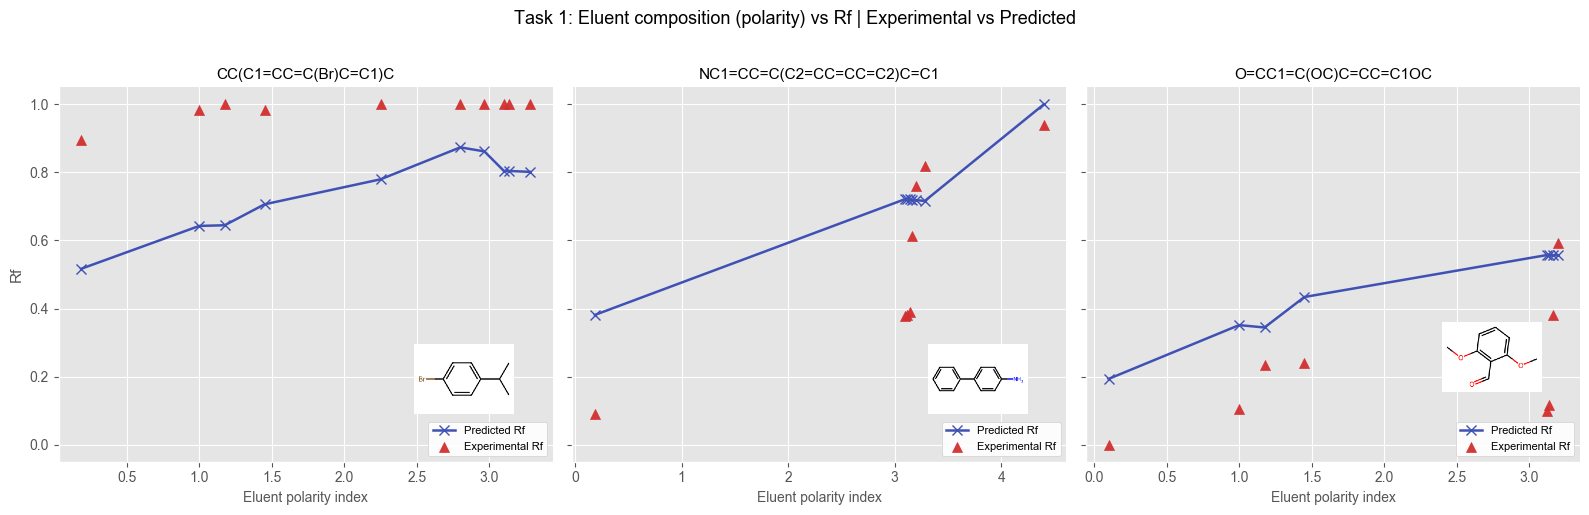

Selected test molecules:
  1. CC(C1=CC=C(Br)C=C1)C
  2. NC1=CC=C(C2=CC=CC=C2)C=C1
  3. O=CC1=C(OC)C=CC=C1OC


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from rdkit import Chem
from rdkit.Chem import Draw


BEST_MODEL_CONFIG = {
    "fp_type": "rdkit",
    "fp_size": 128,
    "hidden_dims": [128, 64, 32],
    "output_activation": "linear",
    "learning_rate": 0.001,
    "max_epoch": 100,
    "batch_size": 32,
    "test_size": 0.2,
    "random_state": 42,
}

# 可选：手动指定测试集中的 3 个 SMILES。
# 若为 None，则自动选择测试集中出现频率最高的前 3 个分子。
SELECTED_TEST_SMILES = None

def build_layer_config(input_dim, hidden_dims, output_activation):
    """根据隐藏层与输出层设置，构建 NeuralNetwork 的层配置。"""
    layers = []
    prev_dim = input_dim
    for h in hidden_dims:
        layers.append((prev_dim, h, "relu"))
        prev_dim = h
    layers.append((prev_dim, 1, output_activation))
    return layers


def build_features_and_targets_with_meta(df, fp_type="morgan", fp_size=128):
    """
    构建特征 X、目标 y，以及用于案例绘图的元数据表。

    其中洗脱剂极性指数按组分加权计算：
        polarity = sum(w_i * polarity_i)，w_i 为各溶剂体积分数。
    """
    solvent_cols = ["H", "EA", "DCM", "MeOH", "Et2O"]
    polarity_scale = {
        "H": 0.1,
        "Et2O": 2.8,
        "DCM": 3.1,
        "EA": 4.4,
        "MeOH": 5.1,
    }

    X_list, y_list = [], []
    meta_rows = []

    for _, row in df.iterrows():
        smiles = row["COMPOUND_SMILES"]
        fp_array = smiles_to_fingerprint(smiles, fp_type=fp_type, fpSize=fp_size)
        solvent_array = row[solvent_cols].values.astype(float)
        X_i = np.concatenate([fp_array, solvent_array])

        total_solvent = solvent_array.sum()
        if total_solvent <= 0:
            continue

        solvent_fraction = solvent_array / total_solvent
        polarity_index = float(
            solvent_fraction[0] * polarity_scale["H"]
            + solvent_fraction[1] * polarity_scale["EA"]
            + solvent_fraction[2] * polarity_scale["DCM"]
            + solvent_fraction[3] * polarity_scale["MeOH"]
            + solvent_fraction[4] * polarity_scale["Et2O"]
        )

        X_list.append(X_i)
        y_list.append(float(row["Rf"]))
        meta_rows.append({
            "COMPOUND_SMILES": smiles,
            "H": float(row["H"]),
            "EA": float(row["EA"]),
            "DCM": float(row["DCM"]),
            "MeOH": float(row["MeOH"]),
            "Et2O": float(row["Et2O"]),
            "polarity_index": polarity_index,
        })

    X = np.array(X_list)
    y = np.array(y_list).reshape(-1, 1)
    meta_df = pd.DataFrame(meta_rows)
    return X, y, meta_df

print("1) Loading data...")
df_case = load_clean_data("TLC_dataset.xlsx")

print("2) Building features using config:")
print(BEST_MODEL_CONFIG)
X_all, y_all, meta_all = build_features_and_targets_with_meta(
    df_case,
    fp_type=BEST_MODEL_CONFIG["fp_type"],
    fp_size=BEST_MODEL_CONFIG["fp_size"],
)

indices = np.arange(X_all.shape[0])
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all,
    y_all,
    indices,
    test_size=BEST_MODEL_CONFIG["test_size"],
    random_state=BEST_MODEL_CONFIG["random_state"],
)

print("3) Training the configurable best-model candidate...")
layer_cfg = build_layer_config(
    input_dim=X_train.shape[1],
    hidden_dims=BEST_MODEL_CONFIG["hidden_dims"],
    output_activation=BEST_MODEL_CONFIG["output_activation"],
)
best_model = NeuralNetwork(layer_cfg)
_ = train_network(
    best_model,
    X_train,
    y_train,
    lr=BEST_MODEL_CONFIG["learning_rate"],
    max_epoch=BEST_MODEL_CONFIG["max_epoch"],
    batch_size=BEST_MODEL_CONFIG["batch_size"],
)

if BEST_MODEL_CONFIG["output_activation"] == "linear":
    y_pred_test = clip_predictions(best_model.forward(X_test))
else:
    y_pred_test = best_model.forward(X_test)

test_mse = mse_loss(y_pred_test, y_test)
print(f"4) Test MSE with current config: {test_mse:.4f}")

# 构建用于绘图的测试集结果表
test_meta = meta_all.iloc[idx_test].copy().reset_index(drop=True)
test_meta["Rf_exp"] = y_test.flatten()
test_meta["Rf_pred"] = y_pred_test.flatten()

# 从测试集中选取 3 个分子
if SELECTED_TEST_SMILES is None:
    selected_smiles = (
        test_meta["COMPOUND_SMILES"]
        .value_counts()
        .head(3)
        .index
        .tolist()
    )
else:
    selected_smiles = list(SELECTED_TEST_SMILES)[:3]

if len(selected_smiles) < 3:
    raise ValueError("Testing dataset has fewer than 3 available molecules.")

print("5) Plotting experimental vs predictive Rf for 3 test molecules...")
plt.style.use("ggplot")
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, (ax, smiles) in enumerate(zip(axes, selected_smiles)):
    one_mol = test_meta[test_meta["COMPOUND_SMILES"] == smiles].copy()
    one_mol = one_mol.sort_values("polarity_index")

    x_pol = one_mol["polarity_index"].to_numpy()
    y_exp = one_mol["Rf_exp"].to_numpy()
    y_pred = one_mol["Rf_pred"].to_numpy()

    ax.plot(
        x_pol,
        y_pred,
        marker="x",
        markersize=7,
        linestyle="-",
        linewidth=1.8,
        color="#3f51b5",
        label="Predicted Rf",
        zorder=2,
    )
    ax.scatter(
        x_pol,
        y_exp,
        marker="^",
        s=52,
        color="#d32f2f",
        alpha=0.95,
        label="Experimental Rf",
        zorder=3,
    )

    # 统一右下角图像和图例风格
    _add_molecule_image(ax, smiles, x_data=x_pol, y_data=np.maximum(y_exp, y_pred))
    _apply_right_bottom(ax, fontsize=8)

    ax.set_title(smiles, fontsize=11)
    ax.set_xlabel("Eluent polarity index", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Rf", fontsize=11)
fig.suptitle(
    "Task 1: Eluent composition (polarity) vs Rf | Experimental vs Predicted",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

print("Selected test molecules:")
for j, smi in enumerate(selected_smiles, 1):
    print(f"  {j}. {smi}")

### Task 2: Find the suitable eluent to separate a mixture

In [73]:
import itertools

print("正在训练模型")
# 生成 0.0 到 1.0，步长 0.05 的所有可能
steps = np.round(np.arange(0.0, 1.05, 0.05), 2)
# 找出所有组合中，5种溶剂体积比例之和等于 1.0 的组合
solvent_grid = np.array([c for c in itertools.product(steps, repeat=5) if np.isclose(sum(c), 1.0)])
print(f"模型构建完成，共计 {solvent_grid.shape[0]} 种溶剂配比方案。\n")

# 定义批量预测方法
def predict_rf_batch(model, smiles, solvent_matrix, fp_type, fp_size, is_linear):
    """
    一次性预测一个分子在所有上万种溶剂组合中的 Rf 值。
    利用 Numpy 的矩阵广播机制，将耗时从几分钟缩短到几毫秒。
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")
        
    # 获取指纹 [fp_size,]
    fp_array = smiles_to_fingerprint(smiles, fp_type=fp_type, fpSize=fp_size)
    
    # 将单个指纹复制 10626 份，与溶剂矩阵拼接
    # fp_batch 维度: (10626, fp_size), solvent_matrix 维度: (10626, 5)
    fp_batch = np.tile(fp_array, (solvent_matrix.shape[0], 1))
    X_batch = np.concatenate([fp_batch, solvent_matrix], axis=1)
    
    # 批量前向传播并压平为一维数组 (10626,)
    preds = model.forward(X_batch).flatten()
    
    # 根据模型输出层类型决定是否截断
    if is_linear:
        preds = clip_predictions(preds)
        
    return preds

# 定义反应体系
reaction1 = {
    'name': 'Buchwald-Hartwig Amination (Reaction 1)',
    'reactants': ['Cc1ccc(Cl)cc1'],               # 原料: 对氯甲苯
    'product': 'Cc1ccc(N2CCOCC2)cc1'              # 产物: N-(4-甲基苯基)吗啉
}

reaction2 = {
    'name': 'Suzuki-Miyaura Coupling (Reaction 2)',
    'reactants': ['COc1cccc(Cl)c1'],                # 原料: 3-甲氧基氯苯
    'product': 'COc1cccc(-c2ccccc2)c1'              # 产物: 3-甲氧基联苯
}


def find_optimal_solvents_advanced(model, reaction, solvent_matrix, config, top_k=5):
    # 从配置字典动态加载参数
    fp_type = config.get("fp_type", "rdkit")
    fp_size = config.get("fp_size", 128)
    is_linear = (config.get("output_activation") == "linear")
    
    print(f"========== 正在分析: {reaction['name']} ==========")
    
    # 1. 预测产物的全部 Rf 值
    prod_smiles = reaction['product']
    prod_preds = predict_rf_batch(model, prod_smiles, solvent_matrix, fp_type, fp_size, is_linear)
    print(f"化合物2(产物)的Rf值范围: {prod_preds.min():.4f} - {prod_preds.max():.4f}")
    
    # 2. 预测所有原料的全部 Rf 值
    react_preds_list = [predict_rf_batch(model, r, solvent_matrix, fp_type, fp_size, is_linear) for r in reaction['reactants']]
    
    # 3. 矢量化条件筛选 (Vectorized Filtering)
    # 条件1：产物 Rf 在 0.2 - 0.3 之间
    valid_mask = (prod_preds >= 0.2) & (prod_preds <= 0.3)
    
    # 条件2：产物与所有原料的 Rf 差值绝对值 > 0.1
    min_delta_rf = np.ones_like(prod_preds) * 999  # 用于记录最小的 Rf 差值以供排序
    
    for r_preds in react_preds_list:
        delta = np.abs(prod_preds - r_preds)
        valid_mask &= (delta > 0.1)
        min_delta_rf = np.minimum(min_delta_rf, delta)
        
    # 提取满足条件的索引
    valid_indices = np.where(valid_mask)[0]
    print(f"找到 {len(valid_indices)} 个满足条件的溶剂组合\n")
    
    if len(valid_indices) == 0:
        print("未找到满足硬性分离条件的溶剂组合。")
        return
        
    # 4. 获取符合条件的组合，并按最小 Rf 差值 (即分离度) 降序排列
    valid_deltas = min_delta_rf[valid_indices]
    sorted_relative_indices = np.argsort(-valid_deltas) # 降序
    best_absolute_indices = valid_indices[sorted_relative_indices][:top_k]
    
    # 5. 按照《参考报告》的格式打印输出
    print(f"反应的最佳溶剂组合 (前{top_k}个):")
    for rank, idx in enumerate(best_absolute_indices):
        solvents = solvent_matrix[idx]
        p_rf = prod_preds[idx]
        
        # 提取原料 Rf 字符串
        r_rfs = [preds[idx] for preds in react_preds_list]
        r_rfs_str = "、".join([f"{r:.4f}" for r in r_rfs])
        delta_rf = min_delta_rf[idx]
        
        print(f"组合 {rank + 1}:")
        print(f"溶剂比例: H={solvents[0]:.2f} EA={solvents[1]:.2f} DCM={solvents[2]:.2f}, MeOH={solvents[3]:.2f} Et2O={solvents[4]:.2f}")
        print(f"产物 Rf值:{p_rf:.4f}、原料Rf值:{r_rfs_str}, Rf差值: {delta_rf:.4f}\n")

# 执行预测
find_optimal_solvents_advanced(best_model, reaction1, solvent_grid, config=BEST_MODEL_CONFIG, top_k=5)

find_optimal_solvents_advanced(best_model, reaction2, solvent_grid, config=BEST_MODEL_CONFIG, top_k=5)


正在训练模型
模型构建完成，共计 10626 种溶剂配比方案。

========== 正在分析: Buchwald-Hartwig Amination (Reaction 1) ==========
化合物2(产物)的Rf值范围: 0.2525 - 0.8015
找到 52 个满足条件的溶剂组合

反应的最佳溶剂组合 (前5个):
组合 1:
溶剂比例: H=0.80 EA=0.00 DCM=0.20, MeOH=0.00 Et2O=0.00
产物 Rf值:0.2952、原料Rf值:0.7318, Rf差值: 0.4366

组合 2:
溶剂比例: H=0.85 EA=0.00 DCM=0.15, MeOH=0.00 Et2O=0.00
产物 Rf值:0.2773、原料Rf值:0.7056, Rf差值: 0.4283

组合 3:
溶剂比例: H=0.80 EA=0.00 DCM=0.15, MeOH=0.00 Et2O=0.05
产物 Rf值:0.2952、原料Rf值:0.7234, Rf差值: 0.4282

组合 4:
溶剂比例: H=0.80 EA=0.00 DCM=0.15, MeOH=0.05 Et2O=0.00
产物 Rf值:0.2935、原料Rf值:0.7212, Rf差值: 0.4276

组合 5:
溶剂比例: H=0.85 EA=0.05 DCM=0.10, MeOH=0.00 Et2O=0.00
产物 Rf值:0.2851、原料Rf值:0.7062, Rf差值: 0.4211

========== 正在分析: Suzuki-Miyaura Coupling (Reaction 2) ==========
化合物2(产物)的Rf值范围: 0.2627 - 0.7113
找到 15 个满足条件的溶剂组合

反应的最佳溶剂组合 (前5个):
组合 1:
溶剂比例: H=0.90 EA=0.05 DCM=0.05, MeOH=0.00 Et2O=0.00
产物 Rf值:0.2969、原料Rf值:0.7938, Rf差值: 0.4969

组合 2:
溶剂比例: H=0.90 EA=0.05 DCM=0.00, MeOH=0.05 Et2O=0.00
产物 Rf值:0.2939、原料Rf值:0.7881, Rf差值: 0.4942

组合 3:
溶